In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import spin_Jx, spin_Jy, spin_Jz, spin_coherent
from scipy.optimize import minimize
from joblib import Parallel, delayed
import time as t
from scipy.linalg import sqrtm, inv, eigh, expm
import matplotlib.animation as animation
from IPython.display import HTML, display
from matplotlib import cm
import glob

In [2]:

# %%
def H(phi=[], beta=1, omega=1, J=1, w = []):
    H_array = np.array([omega*(np.cos(phi[i])*J_x+np.sin(phi[i])*J_y)+beta/(2*J) * J_z2 + w[0]*J_x + w[1]*J_y + w[2]*J_z for i in range(len(phi))])
    return H_array

rng = np.random.default_rng()
J = 4.5
dim = int(2*J+1)
t_steps = 6000
delta_t = 0.001
beta = 1
omega = 1
w = [0, 0, 0]
theta_scs = np.pi/2
phi_scs = 0
J_x = spin_Jx(J).full()
J_y = spin_Jy(J).full()
J_z = spin_Jz(J).full()
J_z2 = J_z @ J_z
obs_0 = J_y

# phi = 2*np.pi*rng.random(t_steps)
# in_state = spin_coherent(J, theta_scs, phi_scs, type = 'dm').full()

def commutator(A, B):
   """Compute the commutator [A, B] = AB - BA."""
   return A @ B - B @ A

def expect(obs, state):
    """Compute the expectation value of an observable."""
    return np.real(np.trace(obs @ state))

def repeated_random_array(total_len, repeat_n, low=0.0, high=1.0):
    n_unique = int(np.ceil(total_len / repeat_n))
    vals = rng.uniform(low, high, size=n_unique)
    arr = np.repeat(vals, repeat_n)
    return arr[:total_len]

def bloch_vector(state_array):
    n_array = [None] * (t_steps + 1)
    n = 1/J * np.array([expect(J_x, state_array[0]), expect(J_y, state_array[0]), expect(J_z, state_array[0])])
    n_array[0] = n
    for i in range(t_steps):
        n = 1/J * np.array([expect(J_x, state_array[i+1]), expect(J_y, state_array[i+1]), expect(J_z, state_array[i+1])])
        n_array[i+1] = n
    return np.array(n_array)


def expectation_values(state_array, obs, steps=1):
    indices = np.arange(0, t_steps + 1, steps)
    expectation = np.array([expect(obs, state_array[i]) for i in indices])
    return expectation * (1/J)


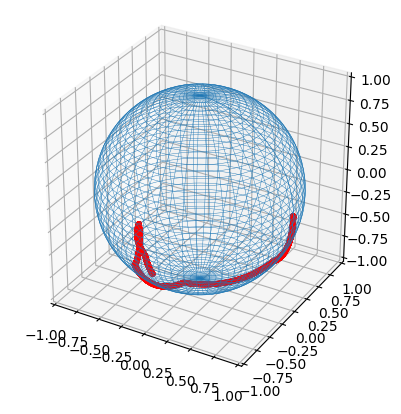

In [3]:
N = 1
t_rotate = t_steps / N
in_state = spin_coherent(J, np.pi/2, 0, type = 'dm').full()
state_array = [None] * (t_steps + 1)
state = in_state
state_array[0] = state
for i in range(t_steps):
    H_c = np.cos(2 * np.pi * i//t_rotate / N) * J_x + np.sin(2 * np.pi * i//t_rotate / N) * J_y
    U_c = expm(-1j * delta_t * H_c)
    U_c_dag = expm(1j * delta_t * H_c)
    state = U_c @ state @ U_c_dag
    state_array[i+1] = state

#Calculate bloch vector norm
mean = bloch_vector(state_array)
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# Plot unit sphere (light mesh)
u = np.linspace(0, 2*np.pi, 100)
v = np.linspace(0, np.pi, 100)
xs = np.outer(np.cos(u), np.sin(v))
ys = np.outer(np.sin(u), np.sin(v))
zs = np.outer(np.ones_like(u), np.cos(v))

ax.plot_wireframe(xs, ys, zs, linewidth=0.3)

# Plot sampled points
ax.scatter(mean[:,0], mean[:,1], mean[:,2], color='red', s=10)

# Make axes equal
ax.set_box_aspect([1,1,1])
ax.set_xlim([-1,1])
ax.set_ylim([-1,1])
ax.set_zlim([-1,1])

plt.show()